# Colab Triple Pipeline API

Phase 1 MVP notebook.

Endpoint: `POST /triple` (multipart form field: `file`).

In [1]:
%pip -q install fastapi uvicorn pyngrok ultralytics pytesseract transformers accelerate pillow opencv-python-headless nest_asyncio requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.9 MB/s eta 0:00:00


In [2]:
!pip install -q transformers accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 62.3 MB/s eta 0:00:00:00:0100:01


In [3]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr tesseract-ocr-rus tesseract-ocr-eng

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-rus.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-rus_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-rus (1:4.00~git30-7274cfa-1.1) ...


In [4]:
import os
import io
import re
import time
import json
import base64
import math
import tempfile
import hashlib
from pathlib import Path
from typing import Any, Dict, List, Optional

import cv2
import numpy as np
import pytesseract
import requests
import torch
from PIL import Image, ImageDraw, ImageOps
from ultralytics import YOLO
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

try:
    from qwen_vl_utils import process_vision_info as _qwen_process_vision_info
except Exception:
    _qwen_process_vision_info = None

QWEN_MODEL_ID = os.getenv("QWEN_MODEL_ID", "Qwen/Qwen2-VL-2B-Instruct")
OCR_LANG = os.getenv("OCR_LANG", "rus+eng")
QWEN_MAX_NEW_TOKENS = int(os.getenv("QWEN_MAX_NEW_TOKENS", "384"))
COLAB_API_KEY = os.getenv("COLAB_API_KEY", "")
MODELS_DIR = os.environ.get("MODELS_DIR", "/content/models")
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = int(os.getenv("YOLO_IMG_SIZE", "1280"))
CONF_THRES = float(os.getenv("YOLO_CONF_THRES", "0.25"))
IOU_THRES = float(os.getenv("YOLO_IOU_THRES", "0.70"))
print(DEVICE)

def qwen_process_vision_info(messages):
    if _qwen_process_vision_info is not None:
        return _qwen_process_vision_info(messages)

    image_inputs = []
    video_inputs = []
    for msg in messages:
        for part in msg.get("content", []):
            if part.get("type") == "image":
                image_inputs.append(part.get("image"))
    return image_inputs, video_inputs

def read_image_with_exif_fix(path: str) -> np.ndarray:
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    arr = np.array(img)
    return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def safe_crop(img: np.ndarray, x1, y1, x2, y2, pad_ratio: float = 0.02):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = [int(round(v)) for v in (x1, y1, x2, y2)]
    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)
    pad_x = int(bw * pad_ratio)
    pad_y = int(bh * pad_ratio)
    x1p = max(0, x1 - pad_x)
    y1p = max(0, y1 - pad_y)
    x2p = min(w, x2 + pad_x)
    y2p = min(h, y2 + pad_y)
    return img[y1p:y2p, x1p:x2p].copy(), (x1p, y1p, x2p, y2p)

def box_center(xyxy):
    x1, y1, x2, y2 = xyxy
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

def overlap_ratio(inner_xyxy, outer_xyxy):
    ax1, ay1, ax2, ay2 = inner_xyxy
    bx1, by1, bx2, by2 = outer_xyxy
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    intersection = iw * ih
    area = max(1.0, (ax2 - ax1) * (ay2 - ay1))
    return intersection / area

def belongs_to_container(child_xyxy, container_xyxy):
    cx, cy = box_center(child_xyxy)
    x1, y1, x2, y2 = container_xyxy
    if x1 <= cx <= x2 and y1 <= cy <= y2:
        return True
    return overlap_ratio(child_xyxy, container_xyxy) >= 0.10

def schema_field_type_map(schema):
    field_types = {}
    for field in schema.get("fields", []):
        field_types[field["key"]] = field.get("type", "text")
    for arr in schema.get("arrays", []):
        for field in arr.get("fields", []):
            field_types[field["key"]] = field.get("type", "text")
    return field_types

def find_array_schema(schema):
    arrays = schema.get("arrays", [])
    return arrays[0] if arrays else None

def schema_for_prompt(schema):
    return {
        "fields": [
            {
                "key": field.get("key"),
                "type": field.get("type", "text"),
                "label": field.get("label"),
            }
            for field in schema.get("fields", [])
        ],
        "arrays": [
            {
                "key": arr.get("key"),
                "rowKey": arr.get("rowKey"),
                "fields": [
                    {
                        "key": field.get("key"),
                        "type": field.get("type", "text"),
                        "label": field.get("label"),
                    }
                    for field in arr.get("fields", [])
                ],
            }
            for arr in schema.get("arrays", [])
        ],
    }

def prompt_for_field_type(field_type):
    normalized = str(field_type or "text").lower()
    prompts = {
        "text": "Read the text exactly as printed. Return only the value.",
        "number": "Return only the number exactly as printed. Digits only.",
        "money": "Return only the monetary amount exactly as printed. Digits and decimal separator only.",
        "date": "Return only the date exactly as printed.",
    }
    return prompts.get(normalized, prompts["text"])

def prompt_for_field(field_name, field_type):
    return f"{prompt_for_field_type(field_type)} Field name: {field_name}."

def coerce(val, ftype):
    if val is None or val == "":
        return None

    field_type = str(ftype or "text").lower()
    if field_type in ("number", "money"):
        if isinstance(val, (int, float)) and not isinstance(val, bool):
            return float(val)
        cleaned = str(val).replace(",", ".")
        cleaned = re.sub(r"[^0-9.\-]", "", cleaned)
        if cleaned in {"", ".", "-", "-."}:
            return None
        try:
            return float(cleaned)
        except Exception:
            return None

    text = str(val).strip()
    return text or None

def normalize_to_schema(data, schema):
    source = data if isinstance(data, dict) else {}
    source_lower = {str(k).lower(): v for k, v in source.items()}
    out = {}

    for field in schema.get("fields", []):
        key = field["key"]
        value = source.get(key)
        if value is None:
            for alt in (key.lower(), key.upper(), key.title()):
                if alt in source:
                    value = source[alt]
                    break
                if alt.lower() in source_lower:
                    value = source_lower[alt.lower()]
                    break
        out[key] = coerce(value, field.get("type"))

    for arr in schema.get("arrays", []):
        key = arr["key"]
        rows = source.get(key)
        if rows is None:
            rows = source.get(key.lower(), source_lower.get(key.lower(), []))
        normalized_rows = []
        if isinstance(rows, list):
            for row in rows:
                if not isinstance(row, dict):
                    continue
                row_lower = {str(k).lower(): v for k, v in row.items()}
                row_out = {}
                for field in arr.get("fields", []):
                    row_key = field["key"]
                    value = row.get(row_key)
                    if value is None:
                        for alt in (row_key.lower(), row_key.upper(), row_key.title()):
                            if alt in row:
                                value = row[alt]
                                break
                            if alt.lower() in row_lower:
                                value = row_lower[alt.lower()]
                                break
                    row_out[row_key] = coerce(value, field.get("type"))
                if any(v not in (None, "", []) for v in row_out.values()):
                    normalized_rows.append(row_out)
        out[key] = normalized_rows

    return out

def make_fallback_envelope(schema, error_text):
    return {
        "file": None,
        "fields": normalize_to_schema({}, schema),
        "confidence": 0.0,
        "scan_time_sec": 0.0,
        "_error": error_text,
    }

def extract_detections(yolo, image_bgr, class_map):
    result = yolo.predict(
        source=image_bgr,
        imgsz=IMG_SIZE,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=0 if DEVICE == "cuda" else "cpu",
        verbose=False,
    )[0]
    detections = []
    if result.boxes is None or len(result.boxes) == 0:
        return detections

    xyxy = result.boxes.xyxy.detach().cpu().numpy()
    cls = result.boxes.cls.detach().cpu().numpy().astype(int)
    conf = result.boxes.conf.detach().cpu().numpy()
    for coords, class_id, score in zip(xyxy, cls, conf):
        label = class_map.get(str(int(class_id)))
        if not label:
            continue
        x1, y1, x2, y2 = [int(v) for v in coords]
        detections.append(
            {
                "class_id": int(class_id),
                "label": label,
                "conf": float(score),
                "xyxy": [x1, y1, x2, y2],
            }
        )
    detections.sort(key=lambda det: (det["xyxy"][1], det["xyxy"][0]))
    return detections

def assign_children_to_rows(detections, schema, label_roles, grouping_rules):
    array_schema = find_array_schema(schema)
    if not array_schema:
        return []

    array_key = array_schema.get("key")
    container_label = None
    if isinstance(grouping_rules, dict):
        container_label = grouping_rules.get("container")
    if not container_label:
        container_label = next(
            (key for key, role in (label_roles or {}).items() if role == "arrayContainer"),
            array_key,
        )

    field_keys = [field["key"] for field in array_schema.get("fields", [])]
    containers = [det for det in detections if det["label"] == container_label]
    containers.sort(key=lambda det: (det["xyxy"][1], det["xyxy"][0]))

    children = {
        key: [det for det in detections if det["label"] == key]
        for key in field_keys
    }
    for key in children:
        children[key].sort(key=lambda det: (det["xyxy"][0], det["xyxy"][1]))

    if not containers:
        if any(children.values()):
            return [{"container": None, "fields": children}]
        return []

    rows = [
        {"container": det, "fields": {key: [] for key in field_keys}}
        for det in containers
    ]

    for key, child_dets in children.items():
        for child in child_dets:
            matches = [
                (idx, overlap_ratio(child["xyxy"], row["container"]["xyxy"]))
                for idx, row in enumerate(rows)
                if belongs_to_container(child["xyxy"], row["container"]["xyxy"])
            ]
            if matches:
                best_idx = max(matches, key=lambda item: item[1])[0]
            else:
                cy = box_center(child["xyxy"])[1]
                best_idx = min(
                    range(len(rows)),
                    key=lambda idx: abs(cy - box_center(rows[idx]["container"]["xyxy"])[1]),
                )
            rows[best_idx]["fields"][key].append(child)

    for row in rows:
        for key in field_keys:
            row["fields"][key].sort(
                key=lambda det: (det["xyxy"][0], det["xyxy"][1])
            )

    return rows


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
cuda


### Run order after a Colab restart

1. Run the install cells (1-3) once per session.
2. Run the config cells (4 + Sync Config) and set `NODE_API_URL` and `NODE_SYNC_TOKEN`.
3. Run the helper and loader cells (7-9).
4. Run the boot-sync cell and confirm the printed summary lists the active models.
5. Run the pipeline cells (13, 16, 20) to define the functions.
6. Run the FastAPI cell (23).
7. Run the uvicorn and tunnel cells (26-28).

If you add a new model in Node mid-session, you do not need to re-run sync. The next `/compare` lazy-downloads it. Re-running sync is harmless.


In [5]:
# === SYNC CONFIG ===
# Edit these values, or set env vars before running, so Colab can reach the Node API.
NODE_API_URL = os.environ.get("NODE_API_URL", "https://fuh01g-23-237-76-82.ru.tuna.am/api")
NODE_SYNC_TOKEN = os.environ.get("NODE_SYNC_TOKEN", "strong_sync_token")
assert NODE_SYNC_TOKEN, "Set NODE_SYNC_TOKEN to the COLAB_SYNC_TOKEN value from api/config/default.json"
print(f"NODE_API_URL = {NODE_API_URL}")


NODE_API_URL = https://fuh01g-23-237-76-82.ru.tuna.am/api


In [6]:
_YOLO_CACHE = {}
_QWEN_MODEL = None
_QWEN_PROCESSOR = None

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def download_with_token(url, dest, token):
    Path(dest).parent.mkdir(parents=True, exist_ok=True)
    response = requests.get(
        url,
        headers={"X-Sync-Token": token},
        stream=True,
        timeout=600,
    )
    response.raise_for_status()
    tmp = dest + ".part"
    with open(tmp, "wb") as f:
        for chunk in response.iter_content(1 << 20):
            if chunk:
                f.write(chunk)
    os.replace(tmp, dest)

def get_yolo_model(model_id, model_version, sha256, download_url, sync_token):
    key = (int(model_id), int(model_version))
    if key in _YOLO_CACHE:
        return _YOLO_CACHE[key]

    local = f"{MODELS_DIR}/m{model_id}/v{model_version}/weights.pt"
    if not (os.path.isfile(local) and sha256_of(local) == sha256):
        download_with_token(download_url, local, sync_token)
        actual = sha256_of(local)
        if actual != sha256:
            raise RuntimeError(f"sha256 mismatch: expected {sha256}, got {actual}")

    _YOLO_CACHE[key] = YOLO(local)
    return _YOLO_CACHE[key]

def load_qwen_model():
    global _QWEN_MODEL, _QWEN_PROCESSOR
    if _QWEN_MODEL is None or _QWEN_PROCESSOR is None:
        _QWEN_PROCESSOR = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
        _QWEN_MODEL = Qwen2VLForConditionalGeneration.from_pretrained(
            QWEN_MODEL_ID,
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            device_map="auto" if DEVICE == "cuda" else None,
        )
        if DEVICE != "cuda":
            _QWEN_MODEL.to(DEVICE)
    return _QWEN_MODEL, _QWEN_PROCESSOR

def run_qwen_prompt_on_image(pil_image, prompt_text):
    model, processor = load_qwen_model()
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_image},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    image_inputs, video_inputs = qwen_process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    device = next(model.parameters()).device
    inputs = inputs.to(device)
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=QWEN_MAX_NEW_TOKENS,
            do_sample=False,
            use_cache=True,
        )
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return output_text.strip()


In [7]:
def pil_to_b64_png(pil_img: Image.Image) -> str:
    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def norm_ws(text: str) -> str:
    return re.sub(r"\\s+", " ", text or "").strip()

def parse_json_from_text(text: str) -> Dict[str, Any]:
    text = (text or "").strip()
    if not text:
        return {}
    try:
        return json.loads(text)
    except Exception:
        match = re.search(r"\\{.*\\}", text, flags=re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except Exception:
                pass
    return {}

def envelope(
    fields: Dict[str, Any],
    items: List[Dict[str, Any]],
    raw: Any,
    annotated_image_b64: Optional[str] = None,
) -> Dict[str, Any]:
    return {
        "fields": fields or {},
        "items": items or [],
        "annotated_image_b64": annotated_image_b64,
        "raw": raw,
    }

def pil_to_bgr(pil_img: Image.Image) -> np.ndarray:
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

In [8]:
!pip install uvicorn fastapi

In [10]:
# === BOOT SYNC: pull all active models from Node ===
print(NODE_SYNC_TOKEN)
print(NODE_API_URL)
def sync_models_from_api():
    """Pull every active detector .pt from the Node API into MODELS_DIR.

    Idempotent: cached files with matching sha256 are skipped.
    Run this cell once per Colab session, or any time you suspect drift.
    """
    response = requests.get(
        f"{NODE_API_URL}/models/active",
        headers={"X-Sync-Token": NODE_SYNC_TOKEN},
        timeout=60,
    )
    response.raise_for_status()
    rows = response.json()
    summary = []
    for model in rows:
        local = f"{MODELS_DIR}/m{model['modelId']}/v{model['modelVersion']}/weights.pt"
        if os.path.isfile(local) and sha256_of(local) == model["sha256"]:
            summary.append((model["modelId"], model["modelVersion"], "cached"))
            continue
        download_with_token(model["downloadUrl"], local, NODE_SYNC_TOKEN)
        actual = sha256_of(local)
        if actual != model["sha256"]:
            raise RuntimeError(
                f"sha256 mismatch for model {model['modelId']}@{model['modelVersion']}: "
                f"expected {model['sha256']}, got {actual}"
            )
        summary.append((model["modelId"], model["modelVersion"], "downloaded"))
    print("sync_models_from_api:", summary)
    return summary


sync_models_from_api()


strong_sync_token
https://fuh01g-23-237-76-82.ru.tuna.am/api


HTTPError: 404 Client Error: Not Found for url: https://fuh01g-23-237-76-82.ru.tuna.am/api/models/active

class=PRICE        conf=0.920 bbox=(1224, 786, 1349, 839)
class=SUM          conf=0.914 bbox=(1097, 899, 1356, 975)
class=PRICE        conf=0.907 bbox=(1222, 679, 1347, 734)
class=ORDER        conf=0.889 bbox=(45, 781, 1372, 900)
class=ORDER        conf=0.877 bbox=(45, 672, 1373, 792)
class=QUANTITY     conf=0.871 bbox=(940, 685, 978, 736)
class=FD           conf=0.870 bbox=(115, 1540, 226, 1601)
class=FB           conf=0.863 bbox=(116, 1590, 322, 1661)
class=NAME         conf=0.862 bbox=(56, 793, 520, 846)
class=QUANTITY     conf=0.844 bbox=(940, 790, 979, 841)
class=DATE         conf=0.763 bbox=(48, 1697, 348, 1775)
class=NAME         conf=0.686 bbox=(55, 685, 502, 741)


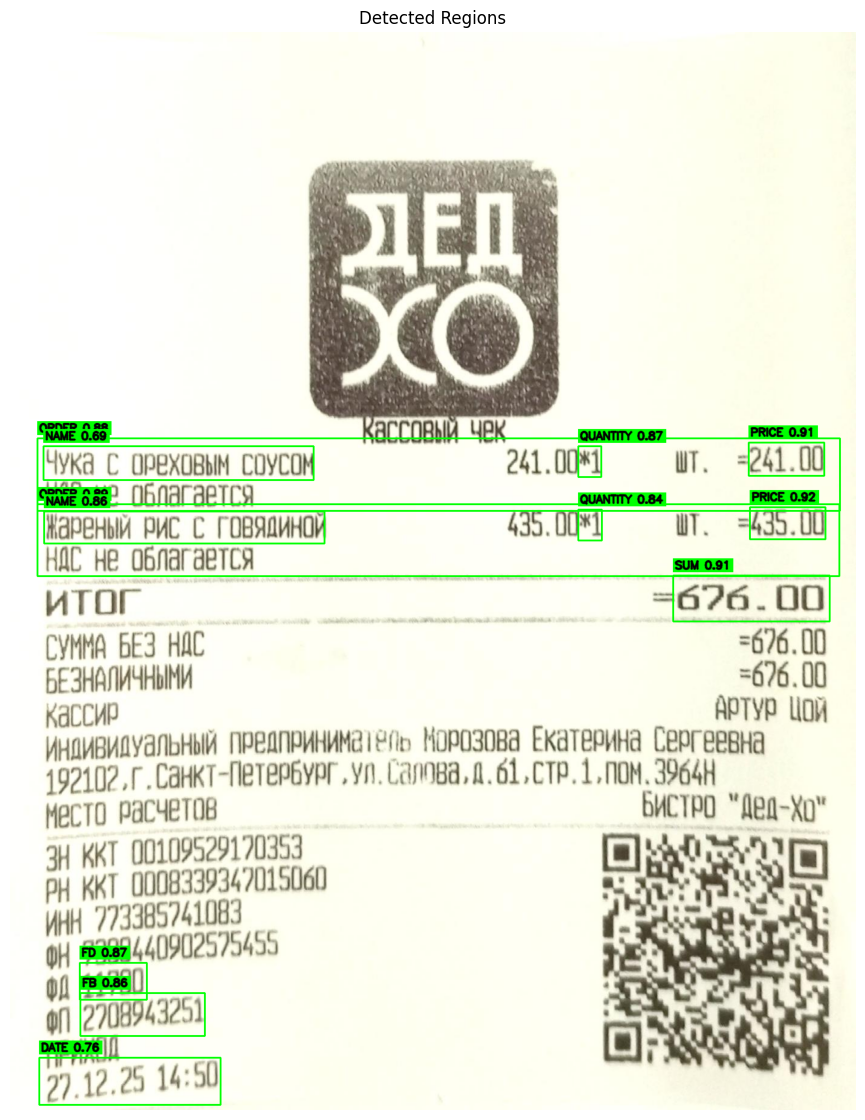

In [ ]:
# Demo cell retired.
# YOLO models are now resolved dynamically per request via get_yolo_model(...).
if False:
    print("Notebook demo disabled")


main

In [ ]:
def apply_main(image_path, *, yolo, schema, class_map, label_roles, grouping_rules):
    image_t0 = time.time()
    image_bgr = read_image_with_exif_fix(image_path)
    detections = extract_detections(yolo, image_bgr, class_map)
    field_type_map = schema_field_type_map(schema)
    used_confidences = []

    def tesseract_config_for_type(field_type):
        kind = str(field_type or "text").lower()
        if kind in ("number", "money"):
            return "--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789.,-"
        if kind == "date":
            return "--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789./:- "
        return "--oem 3 --psm 6"

    def ocr_value(det_list, field_key):
        field_type = field_type_map.get(field_key, "text")
        values = []
        for det in det_list:
            crop_bgr, _ = safe_crop(image_bgr, *det["xyxy"], pad_ratio=0.02)
            if crop_bgr.size == 0:
                continue
            gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
            if gray.shape[0] < 64:
                scale = 64 / max(1, gray.shape[0])
                gray = cv2.resize(
                    gray,
                    (max(1, int(gray.shape[1] * scale)), 64),
                    interpolation=cv2.INTER_CUBIC,
                )
            raw = pytesseract.image_to_string(
                gray,
                lang=OCR_LANG,
                config=tesseract_config_for_type(field_type),
            )
            value = coerce(norm_ws(raw), field_type)
            if value not in (None, ""):
                values.append((det, value))
        if not values:
            return None
        used_confidences.extend(float(item[0]["conf"]) for item in values)
        if str(field_type).lower() == "text":
            joined = " ".join(str(value) for _, value in values).strip()
            return joined or None
        return max(values, key=lambda item: item[0]["conf"])[1]

    raw_fields = {}
    for field in schema.get("fields", []):
        key = field["key"]
        det_list = [det for det in detections if det["label"] == key]
        det_list.sort(key=lambda det: (-det["conf"], det["xyxy"][1], det["xyxy"][0]))
        raw_fields[key] = ocr_value(det_list[:1], key) if det_list else None

    array_schema = find_array_schema(schema)
    if array_schema:
        rows = []
        for row_info in assign_children_to_rows(detections, schema, label_roles, grouping_rules):
            row_out = {}
            for field in array_schema.get("fields", []):
                key = field["key"]
                row_out[key] = ocr_value(row_info["fields"].get(key, []), key)
            if any(value not in (None, "", []) for value in row_out.values()):
                rows.append(row_out)
        raw_fields[array_schema["key"]] = rows

    fields_final = normalize_to_schema(raw_fields, schema)
    confidence = round(float(np.mean(used_confidences)), 4) if used_confidences else 0.0
    result = {
        "file": os.path.basename(image_path),
        "fields": fields_final,
        "confidence": confidence,
        "scan_time_sec": round(time.time() - image_t0, 3),
    }
    return {
        "result_json": result,
        "json_path": None,
        "annotated_image_path": None,
    }


In [ ]:
# Demo cell disabled for the config-driven version.
result = None


next in hypered

In [ ]:
def apply_hyperd(
    image_path,
    *,
    yolo,
    schema,
    class_map,
    label_roles,
    grouping_rules,
    prompt_template="",
):
    image_t0 = time.time()
    image_bgr = read_image_with_exif_fix(image_path)
    detections = extract_detections(yolo, image_bgr, class_map)
    field_type_map = schema_field_type_map(schema)
    used_confidences = []

    def qwen_value(det_list, field_key):
        field_type = field_type_map.get(field_key, "text")
        values = []
        for det in det_list:
            crop_bgr, _ = safe_crop(image_bgr, *det["xyxy"], pad_ratio=0.02)
            if crop_bgr.size == 0:
                continue
            crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(crop_rgb)
            prompt = prompt_for_field(field_key, field_type)
            raw = run_qwen_prompt_on_image(pil_img, prompt)
            cleaned = norm_ws(str(raw).replace("```", "").strip().strip('"').strip("'"))
            value = coerce(cleaned, field_type)
            if value not in (None, ""):
                values.append((det, value))
        if not values:
            return None
        used_confidences.extend(float(item[0]["conf"]) for item in values)
        if str(field_type).lower() == "text":
            joined = " ".join(str(value) for _, value in values).strip()
            return joined or None
        return max(values, key=lambda item: item[0]["conf"])[1]

    raw_fields = {}
    for field in schema.get("fields", []):
        key = field["key"]
        det_list = [det for det in detections if det["label"] == key]
        det_list.sort(key=lambda det: (-det["conf"], det["xyxy"][1], det["xyxy"][0]))
        raw_fields[key] = qwen_value(det_list[:1], key) if det_list else None

    array_schema = find_array_schema(schema)
    if array_schema:
        rows = []
        for row_info in assign_children_to_rows(detections, schema, label_roles, grouping_rules):
            row_out = {}
            for field in array_schema.get("fields", []):
                key = field["key"]
                row_out[key] = qwen_value(row_info["fields"].get(key, []), key)
            if any(value not in (None, "", []) for value in row_out.values()):
                rows.append(row_out)
        raw_fields[array_schema["key"]] = rows

    fields_final = normalize_to_schema(raw_fields, schema)
    confidence = round(float(np.mean(used_confidences)), 4) if used_confidences else 0.0
    result = {
        "file": os.path.basename(image_path),
        "fields": fields_final,
        "confidence": confidence,
        "scan_time_sec": round(time.time() - image_t0, 3),
    }
    return {
        "result_json": result,
        "json_path": None,
        "annotated_image_path": None,
        "debug_json_path": None,
    }


In [ ]:
# Demo cell disabled for the config-driven version.
result = None


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
# Demo cell disabled for the config-driven version.
print(result)


{'file': '1772754756877.jpg', 'fields': {'FB': '2708943251', 'FD': '11700', 'SUM': '676.00', 'DATE': '27.12.25', 'ORDER': [{'ROW_Y': 732, 'NAME': 'Чука с ореховым соусом', 'PRICE': '241.00', 'QUANTITY': '1'}, {'ROW_Y': 840, 'NAME': 'Жаренный рис с говядиной', 'PRICE': '435.00', 'QUANTITY': '1'}]}, 'meta': {'confidence': {'top_fields': {'FB': 0.863, 'FD': 0.8699, 'SUM': 0.9144, 'DATE': 0.763}, 'orders': [{'order_id': 1, 'confidence': 0.8801}, {'order_id': 2, 'confidence': 0.9029}], 'receipt_confidence': 0.8785, 'grouping_confidence': 0.8915}}}
/content/annotated/json/1772754756877.json
/content/annotated/annotated/1772754756877_grouped.jpg
/content/annotated/debug/1772754756877_debug.json


next in queen

In [ ]:
def apply_qwen(image_path, *, schema, prompt_template):
    image_t0 = time.time()
    schema_json = json.dumps(schema_for_prompt(schema), ensure_ascii=False, indent=2)
    if prompt_template and "{{SCHEMA}}" in prompt_template:
        full_prompt = prompt_template.replace("{{SCHEMA}}", schema_json)
    elif prompt_template:
        full_prompt = prompt_template + "\n\nSchema:\n" + schema_json
    else:
        full_prompt = (
            "Extract structured data from the document image and return one valid JSON object.\n\n"
            + "Schema:\n"
            + schema_json
        )

    image = Image.open(image_path).convert("RGB")
    raw_text = run_qwen_prompt_on_image(image, full_prompt)
    parsed = parse_json_from_text(raw_text) or {}
    fields = normalize_to_schema(parsed, schema)
    result = {
        "file": os.path.basename(image_path),
        "fields": fields,
        "confidence": 0.0,
        "scan_time_sec": round(time.time() - image_t0, 3),
    }
    return {
        "result_json": result,
        "json_path": None,
        "raw_text_path": None,
    }


In [ ]:
# Demo cell disabled for the config-driven version.
result = None


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

In [ ]:
# Demo cell disabled for the config-driven version.
print(result)


{'file': '1772754756894.jpg', 'fields': {'DATE': '28.12.25', 'FB': '127.00', 'FD': '459.00', 'SUM': 1577.0, 'ORDER': [{'NAME': 'ФО БО', 'QUANTITY': 1.0, 'PRICE': 459.0}, {'NAME': 'Том Ям', 'QUANTITY': 1.0, 'PRICE': 659.0}, {'NAME': 'Шаверма с курицей в лаваше', 'QUANTITY': 1.0, 'PRICE': 332.0}, {'NAME': 'Морг ягодный 0.2', 'QUANTITY': 1.0, 'PRICE': 127.0}]}, 'confidence': 0.9508, 'scan_time_sec': 32.063}
/content/qwen_apply_out/json/1772754756894.json
/content/qwen_apply_out/raw/1772754756894.txt


In [ ]:
from fastapi import FastAPI, UploadFile, File, Header, Query, Request, Form
from fastapi.responses import JSONResponse
from typing import Optional, Dict, Any
import nest_asyncio
import os
import json
import time
import tempfile
import traceback
from PIL import Image

nest_asyncio.apply()

app = FastAPI(title="colab_app pipelines compare")

def _auth_or_401(x_api_key: Optional[str]):
    if COLAB_API_KEY and x_api_key != COLAB_API_KEY:
        raise ValueError("Invalid API key")

def _open_uploaded_image(image_bytes: bytes) -> Image.Image:
    return Image.open(io.BytesIO(image_bytes)).convert("RGB")

async def _save_upload_to_tmp(file: UploadFile):
    image_bytes = await file.read()
    pil_img = _open_uploaded_image(image_bytes)
    suffix = Path(file.filename or "upload.jpg").suffix or ".jpg"
    fd, image_path = tempfile.mkstemp(suffix=suffix)
    os.close(fd)
    pil_img.save(image_path)
    return pil_img, image_path

def _run_one_pipeline(name, runner, schema_obj):
    t0 = time.time()
    error = None
    error_traceback = None
    result = None
    try:
        payload = runner()
        if isinstance(payload, dict) and "result_json" in payload:
            result = payload["result_json"]
        else:
            result = payload
    except Exception as exc:
        error = str(exc)
        error_traceback = traceback.format_exc()
        result = make_fallback_envelope(schema_obj, error)
    elapsed_ms = int((time.time() - t0) * 1000)
    if DEVICE == "cuda":
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
    return result, error, error_traceback, elapsed_ms

def recommend(response, policy=("hybrid", "qwen", "main")):
    for name in policy:
        result = response.get(name) or {}
        if not result.get("_error") and result.get("fields"):
            return name
    return None

@app.exception_handler(Exception)
async def global_exception_handler(request: Request, exc: Exception):
    return JSONResponse(
        status_code=500,
        content={
            "ok": False,
            "error": str(exc),
            "traceback": traceback.format_exc(),
            "path": str(request.url.path),
            "method": request.method,
        },
    )

@app.get("/health")
def health():
    return {
        "ok": True,
        "device": DEVICE,
        "models_dir": MODELS_DIR,
        "cached_yolo_models": list(_YOLO_CACHE.keys()),
    }

@app.post("/compare")
async def compare_pipelines(
    file: UploadFile = File(...),
    documentTypeKey: str = Form(...),
    documentTypeVersion: int = Form(1),
    schema: str = Form(...),
    promptTemplate: str = Form(""),
    promptVersion: int = Form(1),
    modelId: int = Form(...),
    modelVersion: int = Form(...),
    modelSha256: str = Form(...),
    modelDownloadUrl: str = Form(...),
    syncToken: str = Form(...),
    classMap: str = Form(...),
    labelRoles: str = Form(...),
    groupingRules: str = Form("{}"),
    fieldConfig: str = Form("{}"),
    x_api_key: Optional[str] = Header(default=None),
    save_to_disk: bool = Query(default=False),
):
    _auth_or_401(x_api_key)
    schema_obj = json.loads(schema)
    class_map = json.loads(classMap)
    label_roles = json.loads(labelRoles)
    grouping_rules = json.loads(groupingRules)
    _ = json.loads(fieldConfig)

    yolo = get_yolo_model(
        modelId,
        modelVersion,
        modelSha256,
        modelDownloadUrl,
        syncToken,
    )

    pil_img, image_path = await _save_upload_to_tmp(file)
    try:
        response: Dict[str, Any] = {
            "ok": True,
            "mode": "compare",
            "run_meta": {
                "filename": file.filename,
                "image_w": pil_img.width,
                "image_h": pil_img.height,
                "device": DEVICE,
                "timings_ms": {},
                "document_type_key": documentTypeKey,
                "document_type_version": documentTypeVersion,
                "prompt_version": promptVersion,
                "model_id": modelId,
                "model_version": modelVersion,
            },
            "main": make_fallback_envelope(schema_obj, "not executed"),
            "qwen": make_fallback_envelope(schema_obj, "not executed"),
            "hybrid": make_fallback_envelope(schema_obj, "not executed"),
            "errors": {},
            "tracebacks": {},
            "recommended_for_production": None,
        }

        runners = {
            "main": lambda: apply_main(
                image_path,
                yolo=yolo,
                schema=schema_obj,
                class_map=class_map,
                label_roles=label_roles,
                grouping_rules=grouping_rules,
            ),
            "qwen": lambda: apply_qwen(
                image_path,
                schema=schema_obj,
                prompt_template=promptTemplate,
            ),
            "hybrid": lambda: apply_hyperd(
                image_path,
                yolo=yolo,
                schema=schema_obj,
                class_map=class_map,
                label_roles=label_roles,
                grouping_rules=grouping_rules,
                prompt_template=promptTemplate,
            ),
        }

        for name, runner in runners.items():
            result, err, tb, ms = _run_one_pipeline(name, runner, schema_obj)
            response[name] = result
            response["run_meta"]["timings_ms"][name] = ms
            if err:
                response["errors"][name] = err
                response["tracebacks"][name] = tb
                response["ok"] = False

        response["recommended_for_production"] = recommend(response)
        return JSONResponse(response)
    finally:
        try:
            os.remove(image_path)
        except Exception:
            pass

print("FastAPI app ready.")
print("Compare pipelines -> POST /compare")
print("Expected functions -> apply_main, apply_qwen, apply_hyperd")


FastAPI app ready.
Compare pipelines -> POST /compare
Production hybrid -> POST /predict
Unified endpoint  -> POST /pipeline?mode=compare   or   /pipeline?mode=prod
Expected wrappers -> apply_main, apply_qwen, apply_hyperd


In [ ]:
import threading, time, socket, asyncio, uvicorn

PORT = 8001



def _wait_port(host, port, timeout=10):
    t0 = time.time()
    while time.time() - t0 < timeout:
        s = socket.socket()
        s.settimeout(1)
        try:
            s.connect((host, port))
            s.close()
            return True
        except:
            time.sleep(0.2)
        finally:
            try:
                s.close()
            except:
                pass
    return False

def run_api():
    config = uvicorn.Config(app, host="0.0.0.0", port=PORT, log_level="info")
    server = uvicorn.Server(config)
    asyncio.run(server.serve())

api_thread = threading.Thread(target=run_api, daemon=True)
api_thread.start()

ok = _wait_port("127.0.0.1", PORT, timeout=10)
print(f"API server {'started' if ok else 'failed to start'} on http://127.0.0.1:{PORT}")

INFO:     Started server process [22531]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8001 (Press CTRL+C to quit)


API server started on http://127.0.0.1:8001


In [ ]:
# Open a public tunnel to port 8000
# Optionally set NGROK_AUTH_TOKEN env var before running this cell.
from pyngrok import ngrok

token = "28C9LqGaeUk9JX9QP78bP0BcF3x_khf9f28PVNGZN78kaiQW"
if token:
    ngrok.set_auth_token(token)

public_url = ngrok.connect(8001, bind_tls=True)
print("Public URL:", public_url)
print("Use this in basic_app Phase 2 as COLAB_TRIPLE_URL")

Public URL: NgrokTunnel: "https://5a6a-35-231-49-49.ngrok-free.app" -> "http://localhost:8001"
Use this in basic_app Phase 2 as COLAB_TRIPLE_URL


In [ ]:
# Cloudflare Tunnel for Colab -> public HTTPS URL to local port 8001
import os, re, time, subprocess, signal

PORT = 8001

# kill old cloudflared if any
subprocess.run("pkill -f cloudflared", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# download cloudflared if missing
if not os.path.exists("/tmp/cloudflared"):
    !wget -q -O /tmp/cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
    !chmod +x /tmp/cloudflared

# start tunnel
proc = subprocess.Popen(
    ["/tmp/cloudflared", "tunnel", "--url", f"http://127.0.0.1:{PORT}", "--no-autoupdate"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None
start = time.time()

while time.time() - start < 30:
    line = proc.stdout.readline().strip()
    if line:
        print(line)
        m = re.search(r"https://[-a-zA-Z0-9]+\.trycloudflare\.com", line)
        if m:
            public_url = m.group(0)
            break

if public_url:
    print("\nPublic URL:", public_url)
    print("Use this in basic_app Phase 2 as COLAB_TRIPLE_URL")
else:
    raise RuntimeError("Could not get Cloudflare tunnel URL")

2026-04-23T19:11:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-23T19:11:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-23T19:11:23Z INF +--------------------------------------------------------------------------------------------+
2026-04-23T19:11:23Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-04-23T19:11:23Z INF |  https://dairy-skill-frankfurt-duo.trycloudflare.com  

In [ ]:
print('hello')

hello


In [ ]:
##!fuser -k 8001/tcp || true

In [ ]:
import os, re, subprocess, time, signal, atexit, textwrap
from IPython.display import display, Markdown

PORT = 8001
TOKEN = os.getenv("TUNA_TOKEN", "tt_g4mi0fvh2t2zox2eb9c3pgdca1harxat")  # or set in Colab Secrets/env

# install tuna cli in Colab/Linux
subprocess.run(
    'bash -lc \'set -e; if ! command -v tuna >/dev/null 2>&1; then sh -c "$(curl -sSLf https://releases.tuna.am/tuna/get.sh)"; fi; tuna help >/dev/null\'',
    shell=True,
    check=True,
)

env = os.environ.copy()
env["TUNA_TOKEN"] = TOKEN
env["PYTHONUNBUFFERED"] = "1"

# start tunnel
proc = subprocess.Popen(
    ["tuna", "http", str(PORT), "--inspect=false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)

def _cleanup():
    try:
        proc.terminate()
    except:
        pass

atexit.register(_cleanup)

public_url = None
url_pattern = re.compile(r"https?://[^\s]+")

start = time.time()
while time.time() - start < 30:
    line = proc.stdout.readline()
    if not line:
        time.sleep(0.2)
        continue
    print(line, end="")
    m = url_pattern.search(line)
    if m:
        public_url = m.group(0)
        break

if not public_url:
    raise RuntimeError("Could not detect Tuna public URL from startup output.")

print("Public URL:", public_url)
print("Use this in basic_app Phase 2 as COLAB_TRIPLE_URL")

INFO[19:11:23] Welcome to Tuna                              
INFO[19:11:25] Account: mahmodahmad003@gmail.com (Free)     
INFO[19:11:26] Forwarding https://np22ll-35-231-49-49.ru.tuna.am -> 127.0.0.1:8001 
Public URL: https://np22ll-35-231-49-49.ru.tuna.am
Use this in basic_app Phase 2 as COLAB_TRIPLE_URL
